# Machine Learning Classifier for Lung Disease

## Download Dataset

In [2]:
import kagglehub
import shutil
from pathlib import Path

path = Path(kagglehub.dataset_download("gunasathwikagone/lung-disease-image-dataset"))
print("Path to dataset files:", path)

dst = Path.cwd() / path.name

shutil.copytree(path, dst, dirs_exist_ok=True)

c:\Users\KURT\Git\csc713m-mco\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\KURT\.cache\kagglehub\datasets\gunasathwikagone\lung-disease-image-dataset\versions\1


KeyboardInterrupt: 

In [ ]:
import os
import shutil
from tqdm import tqdm

splits = ['train', 'test', 'val']
labels = ['COVID-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']

src = "1/dataset_all"
dest = "1/dataset_combined"

if not os.path.exists("1/dataset_combined"):
    os.makedirs(dest)
    print(f"Created directory: {dest}")

for label in labels:
    dest_label_path = os.path.join(dest, label)
    os.makedirs(dest_label_path, exist_ok=True)
    
    for split in splits:
        src_label_path = os.path.join(src, split, label)
        
        if os.path.exists(src_label_path):
            for file in tqdm(os.listdir(src_label_path), desc=f"Copying files from {src_label_path}"):
                src_file = os.path.join(src_label_path, file)
                
                if os.path.isfile(src_file):
                    dest_file = os.path.join(dest_label_path, file)
                    
                    if (not os.path.exists(dest_file)):
                        shutil.copy2(src_file, dest_file)
        else:
            print(f"  Warning: Path {src_label_path} not found. Skipping.")

Copying files from 1/dataset_all\val\Normal: 100%|██████████| 490/490 [00:00<00:00, 2784.22it/s]
Copying files from 1/dataset_all\train\Pneumonia-Bacterial: 100%|██████████| 2250/2250 [00:00<00:00, 2860.53it/s]
Copying files from 1/dataset_all\test\Pneumonia-Bacterial: 100%|██████████| 301/301 [00:00<00:00, 1936.54it/s]
Copying files from 1/dataset_all\val\Pneumonia-Bacterial: 100%|██████████| 450/450 [00:00<00:00, 2395.34it/s]
Copying files from 1/dataset_all\train\Pneumonia-Viral: 100%|██████████| 1242/1242 [00:00<00:00, 2397.33it/s]
Copying files from 1/dataset_all\test\Pneumonia-Viral: 100%|██████████| 166/166 [00:00<00:00, 2289.75it/s]
Copying files from 1/dataset_all\val\Pneumonia-Viral: 100%|██████████| 248/248 [00:00<00:00, 1807.83it/s]


In [ ]:
from collections import Counter
from PIL import Image

def list_resolutions(folder_path:str):
    resolutions = []

    for filename in tqdm(os.listdir(folder_path)):
        if filename.lower().endswith(('.jpg')):
            try:
                with Image.open(os.path.join(folder_path, filename)) as img:
                    resolutions.append(f"{img.width}x{img.height}")
            except Exception as e:
                print(f"Could not read {filename}: {e}")

    stats = Counter(resolutions)

    print("Resolution | Count")
    print("-" * 20)
    for res, count in stats.most_common():
        print(f"{res} | {count}")

In [4]:
list_resolutions("1/dataset_combined/COVID-19")
list_resolutions("1/dataset_combined/Normal")
list_resolutions("1/dataset_combined/Pneumonia-Bacterial")
list_resolutions("1/dataset_combined/Pneumonia-Viral")

100%|██████████| 1281/1281 [00:01<00:00, 897.44it/s]


Resolution | Count
--------------------
1024x1024 | 132
2000x2000 | 86
400x300 | 45
1200x1200 | 33
480x480 | 22
4248x3480 | 16
534x462 | 15
3050x2539 | 11
640x524 | 9
2836x2336 | 6
2500x2048 | 5
2498x1971 | 4
1024x843 | 4
2498x1970 | 3
2828x2320 | 3
1024x922 | 3
1534x1517 | 3
1024x842 | 3
1024x961 | 3
1199x1200 | 3
640x547 | 3
604x499 | 2
1024x862 | 2
895x734 | 2
2498x1969 | 2
2497x1970 | 2
4200x3408 | 2
763x768 | 2
2169x1852 | 2
1024x839 | 2
1024x918 | 2
1005x1024 | 2
1024x966 | 2
1024x840 | 2
1024x912 | 2
1200x1197 | 2
1200x1176 | 2
571x524 | 2
640x589 | 2
640x552 | 2
640x591 | 2
969x845 | 2
961x797 | 2
2200x1802 | 2
2000x1390 | 2
936x768 | 1
952x1024 | 1
1024x783 | 1
600x492 | 1
1151x972 | 1
1050x973 | 1
585x492 | 1
1772x1794 | 1
1743x1674 | 1
556x557 | 1
872x648 | 1
3052x2541 | 1
1440x1420 | 1
849x695 | 1
895x732 | 1
881x663 | 1
1374x1078 | 1
785x664 | 1
972x733 | 1
890x662 | 1
732x705 | 1
714x638 | 1
1962x1862 | 1
1374x1025 | 1
224x224 | 1
513x460 | 1
2394x1969 | 1
2371x1971 | 1
2

100%|██████████| 3270/3270 [00:03<00:00, 1010.30it/s]


Resolution | Count
--------------------
1024x1024 | 1288
400x300 | 624
1472x1171 | 2
1480x1228 | 2
1616x1318 | 2
1284x1013 | 2
1778x1356 | 2
1268x924 | 2
1450x1210 | 2
1624x1341 | 2
1422x1066 | 2
1962x2169 | 2
1558x1279 | 2
1836x1592 | 2
1438x1067 | 1
1836x1719 | 1
1500x1051 | 1
1296x1052 | 1
1574x1229 | 1
1572x1194 | 1
1310x951 | 1
1296x800 | 1
1430x1194 | 1
2572x2476 | 1
1654x1051 | 1
1430x1005 | 1
1384x1121 | 1
1546x1314 | 1
1114x815 | 1
1840x1283 | 1
1256x1097 | 1
1348x1028 | 1
1620x1480 | 1
1562x1021 | 1
1572x1125 | 1
1802x1110 | 1
2090x1858 | 1
1422x1152 | 1
1810x1434 | 1
1618x1279 | 1
1600x1125 | 1
1974x1306 | 1
1384x1167 | 1
1450x1144 | 1
1468x993 | 1
1504x1174 | 1
1520x1306 | 1
1808x1507 | 1
1196x974 | 1
1422x1191 | 1
1360x1341 | 1
1114x843 | 1
2538x1897 | 1
1584x1237 | 1
1746x1392 | 1
1792x1623 | 1
1840x1480 | 1
1654x1364 | 1
1588x1217 | 1
1310x1071 | 1
1592x1411 | 1
1388x1063 | 1
1392x998 | 1
1620x1151 | 1
1300x974 | 1
2064x1951 | 1
1646x1299 | 1
1634x1272 | 1
1570x1156 | 1


100%|██████████| 3001/3001 [00:02<00:00, 1014.49it/s]


Resolution | Count
--------------------
400x300 | 498
1008x704 | 5
1064x760 | 5
1080x728 | 5
1072x648 | 5
976x672 | 5
992x592 | 5
1008x680 | 4
1192x760 | 4
1000x568 | 4
1096x784 | 4
1016x680 | 4
1160x800 | 4
1008x600 | 4
920x544 | 4
1128x752 | 4
1216x872 | 4
1176x784 | 3
904x576 | 3
920x680 | 3
1008x728 | 3
976x608 | 3
1024x632 | 3
1328x968 | 3
1136x824 | 3
1136x768 | 3
896x680 | 3
1152x856 | 3
1136x688 | 3
1080x720 | 3
1064x592 | 3
952x632 | 3
992x608 | 3
1152x736 | 3
1176x760 | 3
1320x1016 | 3
1016x560 | 3
936x616 | 3
1232x952 | 3
1072x664 | 3
992x776 | 3
904x568 | 3
976x624 | 3
1032x600 | 3
1096x832 | 3
1008x584 | 3
1152x672 | 3
1072x744 | 3
1000x744 | 3
968x576 | 3
1000x704 | 3
1176x800 | 3
1120x744 | 3
1024x696 | 3
1032x680 | 3
992x712 | 3
1064x696 | 3
1024x624 | 3
984x584 | 3
992x520 | 3
992x616 | 3
920x632 | 3
880x584 | 3
1000x680 | 3
1456x1104 | 3
1000x624 | 3
992x600 | 3
1008x576 | 3
920x648 | 3
936x624 | 3
928x656 | 3
992x736 | 3
1064x632 | 3
1008x640 | 3
1088x712 | 3
1152x78

100%|██████████| 1656/1656 [00:01<00:00, 936.82it/s]

Resolution | Count
--------------------
400x300 | 304
1336x1056 | 3
984x656 | 3
1216x672 | 3
1312x800 | 3
1136x680 | 3
1128x736 | 3
1432x944 | 2
1208x776 | 2
1288x944 | 2
1000x664 | 2
1216x744 | 2
1392x832 | 2
1368x928 | 2
1168x776 | 2
1288x728 | 2
1504x992 | 2
1152x728 | 2
1160x768 | 2
1040x688 | 2
984x552 | 2
1288x840 | 2
1184x752 | 2
1144x928 | 2
1136x840 | 2
1024x640 | 2
1352x960 | 2
952x584 | 2
1232x808 | 2
1128x720 | 2
1512x1088 | 2
1192x856 | 2
1080x752 | 2
952x544 | 2
1408x968 | 2
1368x912 | 2
1216x880 | 2
1360x952 | 2
1168x608 | 2
1120x592 | 2
1144x632 | 2
1280x920 | 2
1720x1240 | 2
1200x784 | 2
1400x1072 | 2
1448x880 | 2
1320x1000 | 2
1408x976 | 2
1312x824 | 2
1120x680 | 2
1072x648 | 2
1136x576 | 2
1352x840 | 2
1440x896 | 2
984x672 | 2
1104x824 | 2
1152x664 | 2
1280x856 | 2
1088x688 | 2
1336x936 | 2
1304x712 | 2
1616x1024 | 2
1296x832 | 2
1368x904 | 2
1304x968 | 2
1264x704 | 2
1472x1176 | 2
1192x864 | 2
920x512 | 2
1448x1112 | 2
1336x992 | 2
1416x1072 | 2
1416x864 | 2
1072x62

In [5]:
def count_images(path):
    entries = os.listdir(path)
    file_count = len([f for f in entries if os.path.isfile(os.path.join(path, f))])
    return file_count

In [6]:
import matplotlib.pyplot as plt
from pathlib import Path

classes = {
    "COVID-19":                 "1/dataset_combined/COVID-19",
    "Normal":                   "1/dataset_combined/Normal",
    "Pneumonia-Bacterial":      "1/dataset_combined/Pneumonia-Bacterial",
    "Pneumonia-Viral":          "1/dataset_combined/Pneumonia-Viral"
}

labels = list(classes.keys())
paths = list(classes.values())
counts = [count_images(p) for p in paths]

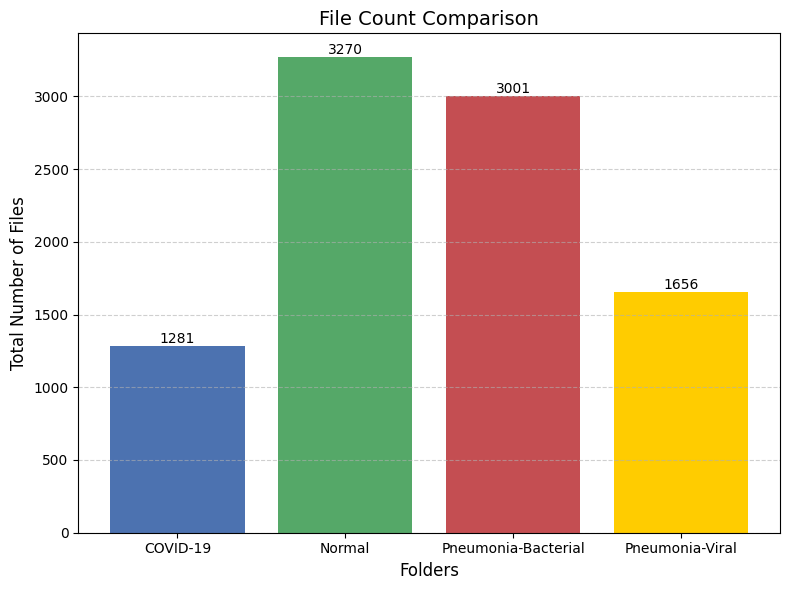

In [ ]:
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts, color=['#4C72B0', '#55A868', '#C44E52', '#FFCC00'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, yval, ha='center', va='bottom')

plt.xlabel('Folders', fontsize=12)
plt.ylabel('Total Number of Files', fontsize=12)
plt.title('Image Count Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

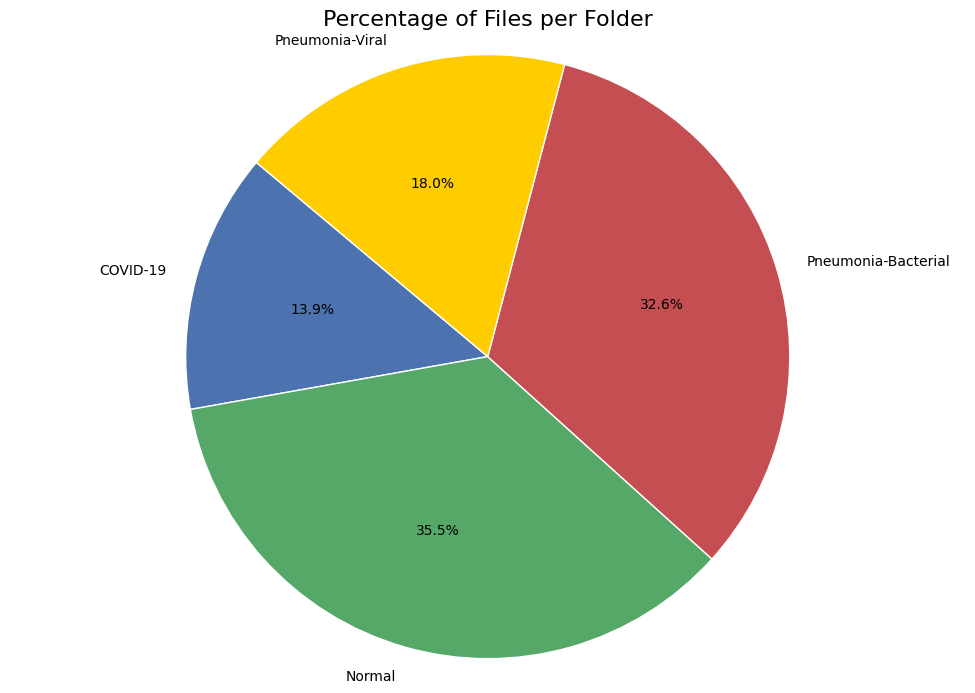

In [ ]:
plt.figure(figsize=(10, 7))

colors = ['#4C72B0', '#55A868', '#C44E52', '#FFCC00']

plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
        wedgeprops={'edgecolor': 'white'})

plt.axis('equal') 

plt.title('Percentage of all Classes', fontsize=16)

plt.tight_layout()